<a href="https://colab.research.google.com/github/raghav-pant17/ANN_diabetes_prediction_model/blob/main/CNN_Fashion_MNIST_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
#loading the MNIST Dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Number of training images:", x_train.shape[0])

Number of training images: 60000


In [ ]:
print("Number of test images:", x_test.shape[0])

Number of test images: 10000


In [ ]:
print("Image dimensions:", x_train.shape[1:])

Image dimensions: (28, 28)


In [ ]:
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0

print("Minimum pixel value:", x_train.min(), "and maximum pixel value:", x_train.max())

Minimum pixel value: 0.0 and maximum pixel value: 1.0


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

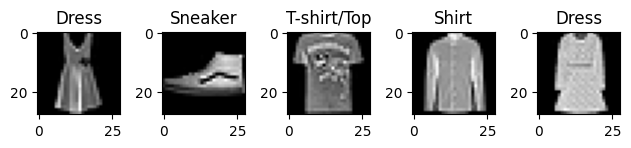

In [ ]:
import random

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

for i in range(5):
    plt.subplot(1, 5, i + 1)
    num = random.randint(0, 59999)
    plt.imshow(x_train[num], cmap="gray")
    plt.title(class_names[y_train[num]])
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([
    layers.Input(shape=(28,28,1),
                 name="input_layer"),#[1,28,28]
    layers.Conv2D(filters=16, kernel_size=(3,3), activation='relu',
                  name="conv_layer_1"),#[1,26,26,16]
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_1"), #[1,13,13,16]
    layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',
                  name="conv_layer_2"), #[1,11,11,32]
    layers.MaxPool2D(pool_size=(2,2), name="max_pool_2"), #[1,5,5,32]
    layers.Flatten(name="flatten_layer"), #5x5x32 = 800 values
    layers.Dense(64, activation='relu', name="hidden_layer_1"),
    layers.Dense(64, activation='relu', name="hidden_layer_2"),
    layers.Dense(units=10, activation='softmax', name="output_layer")
])

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=20, batch_size=64)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 33ms/step - accuracy: 0.7899 - loss: 0.5777
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8656 - loss: 0.3740
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.8814 - loss: 0.3243
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.8927 - loss: 0.2934
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - accuracy: 0.8990 - loss: 0.2747
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9088 - loss: 0.2515
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.9147 - loss: 0.2329
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.9175 - loss: 0.2207
Epoch 9/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - accuracy: 0.9233 - loss: 0.2081
Epoch 10/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 34ms/step - accuracy: 0.9277 - loss: 0.1938
Epoch 11/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.9313 - loss: 0.1854
Epoch 12/20
938/938 ━━━━━━━━━━

In [ ]:
print(history.history)

{'accuracy': [0.7899333238601685, 0.8656333088874817, 0.8813999891281128, 0.8927333354949951, 0.8990166783332825, 0.9087833166122437, 0.9146666526794434, 0.9175166487693787, 0.9232833385467529, 0.9276833534240723, 0.9312999844551086, 0.9354333281517029, 0.9384499788284302, 0.9427499771118164, 0.9442166686058044, 0.9478833079338074, 0.949833333492279, 0.9528166651725769, 0.9557666778564453, 0.9572166800498962], 'loss': [0.5776522159576416, 0.37398847937583923, 0.3242550194263458, 0.2934151589870453, 0.27465108036994934, 0.25152304768562317, 0.23294025659561157, 0.22071047127246857, 0.20809532701969147, 0.19377093017101288, 0.18540099263191223, 0.1747596561908722, 0.16573916375637054, 0.1557774543762207, 0.14749778807163239, 0.13903239369392395, 0.13177715241909027, 0.12688663601875305, 0.11809951066970825, 0.11301098018884659]}


In [ ]:
final_training_accuracy = history.history["accuracy"][-1]
final_training_loss = history.history["loss"][-1]


print(
    "Final Training Accuracy:",
    final_training_accuracy,
    "\nFinal Training Loss:",
    final_training_loss
)

Final Training Accuracy: 0.9572166800498962 
Final Training Loss: 0.11301098018884659


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9001 - loss: 0.3402
Test Loss: 0.34021955728530884
Test Accuracy: 0.9000999927520752


In [ ]:
y_pred_probability = model.predict(x_test)

print(y_pred_probability.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
(10000, 10)


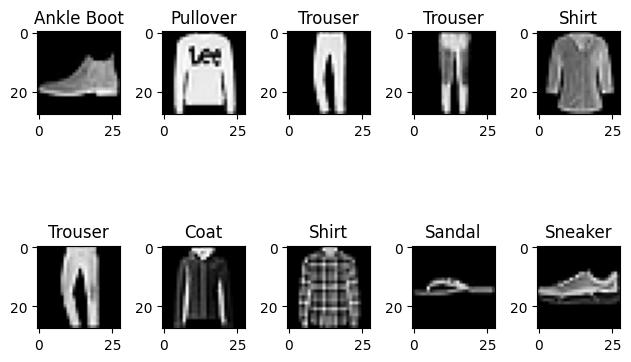

In [ ]:
y_pred = np.argmax(
    y_pred_probability,
    axis=1
)

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(class_names[y_test[i]])
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9001 - loss: 0.3402
Test Accuracy: 0.9000999927520752


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[842   1   8  22  12   0 110   0   5   0]
 [  1 983   0   8   4   0   3   0   1   0]
 [ 26   0 724   6 183   0  61   0   0   0]
 [  8   4   5 917  39   0  24   0   3   0]
 [  0   0   4  11 936   0  47   0   2   0]
 [  0   0   0   0   0 979   0  15   1   5]
 [ 92   1  32  26 111   0 732   0   6   0]
 [  0   0   0   0   0  12   0 980   0   8]
 [ 10   3   1   3  13   1   2   1 966   0]
 [  0   0   0   0   0   5   0  52   1 942]]


In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

 T-shirt/Top       0.86      0.84      0.85      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.94      0.72      0.82      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.72      0.94      0.81      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      0.73      0.74      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.97      0.97      1000
  Ankle Boot       0.99      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



**Ques 1: Why are CNNs more suitable than Artificial Neural Networks (ANNs) for image classification?**

Ans 1: CNNs are better for image classification because they can understand spatial information in an image. They use filters to find useful features like edges, shapes, textures and patterns.

In a normal ANN the image has to be flattened into one long list of numbers. This makes it harder to the network to understand which pixels are neighbors and also has more parameters. This is avoided in CNNs by looking at small chunks of the image and applying the same filters across the image.

**Ques 2: What is the purpose of a Convolution layer?**

Ans 2: The main purpose of a Convolution layer is to find useful features in an image. It uses small filters, known as kernels, that pass over the image looking for particular patterns.

At first, the filters might pick up simple features like edges and lines. As we go deeper into the network the layers can learn more complex features such as shapes and textures.

**Ques 3: Why is Max Pooling used in CNNs?**

Ans 3: Max Pooling is mainly used to reduce the size of the feature maps while preserving the most important information.

For instance, in a 2 x 2 Max Pooling operation, the max from each 2 x 2 area is selected. This makes the data smaller, the computation less, and the model less sensitive to small changes in the position of an object.

**Ques 4: Why is the Flatten layer required before the Dense layers?**

Ans 4: The Convolution and Max Pooling layers produce multi-dimensional feature maps. However, a Dense layer expects its input to be a one-dimensional vector.

The Flatten layer transforms the feature maps into a single long vector, which can then be passed to the Dense layer for classification.

**Ques 5: Why is the Softmax activation function used in the output layer?**

Ans 5: Softmax converts the model's outputs into probabilities for each class, and the sum of all probabilities is always 1 (or 100%). It is used because Fashion-MNIST has 10 classes, so the model can assign a probability to each class and choose the class with the highest probability.

**Ques 6: How does the Adam optimizer help in training the CNN?**

Ans 6: The weights of the CNN are updated using Adam during training. Once the model has made a prediction the error is calculated and backpropagation is used to determine how the weights should be changed.

Adam uses this information to adjust the weight and it also automatically adapts the learning rate for different parameters. This generally helps the model to learn faster and makes the training process more efficient and stable.